In [ ]:
#Importar paquete
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline

In [ ]:
#dataset
df_cities = pd.read_csv("california_cities.csv")

#show all
display(df_cities.head())
display(df_cities.info())

# delete nules
df_cities = df_cities.dropna()

# show all already deleted
display(df_cities.info())

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    object 
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         434 non-null    float64
 5   elevation_ft        470 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    480 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    481 non-null    float64
 10  area_total_km2      477 non-null    float64
 11  area_land_km2       478 non-null    float64
 12  area_water_km2      478 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 52.8+ KB


None

<class 'pandas.core.frame.DataFrame'>
Index: 427 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          427 non-null    int64  
 1   city                427 non-null    object 
 2   latd                427 non-null    float64
 3   longd               427 non-null    float64
 4   elevation_m         427 non-null    float64
 5   elevation_ft        427 non-null    float64
 6   population_total    427 non-null    int64  
 7   area_total_sq_mi    427 non-null    float64
 8   area_land_sq_mi     427 non-null    float64
 9   area_water_sq_mi    427 non-null    float64
 10  area_total_km2      427 non-null    float64
 11  area_land_km2       427 non-null    float64
 12  area_water_km2      427 non-null    float64
 13  area_water_percent  427 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 50.0+ KB


None

In [ ]:
def scatter_plot(df, x_col, y_col, cat_col=None, size=50, scale=1, legend_mode="legend"):
    """
    Función para pintar diagramas de dispersión personalizados.
    
    Parámetros:
    df: DataFrame
    x_col: columna numérica eje X
    y_col: columna numérica eje Y
    cat_col: columna categórica para color (opcional)
    size: valor numérico o nombre de columna para tamaño
    scale: escala multiplicadora para tamaño si size es columna
    legend_mode: "legend" o "colorbar"
    """
    
    plt.figure(figsize=(10,6))
    
    #Tamaño
    if isinstance(size, str):
        sizes = df[size] * scale
    else:
        sizes = size
    
    # Ccategórica
    if cat_col is not None:
        if pd.api.types.is_numeric_dtype(df[cat_col]) and legend_mode == "colorbar":
            sc = plt.scatter(df[x_col], df[y_col], c=df[cat_col], s=sizes, cmap="viridis", alpha=0.7)
            plt.colorbar(sc, label=cat_col)
        else:
            sns.scatterplot(data=df, x=x_col, y=y_col, hue=cat_col, size=None,
                            sizes=(20, 200), legend=True)
    else:
        plt.scatter(df[x_col], df[y_col], s=sizes, alpha=0.7)
    
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Scatter plot: {x_col} vs {y_col}")
    plt.show()

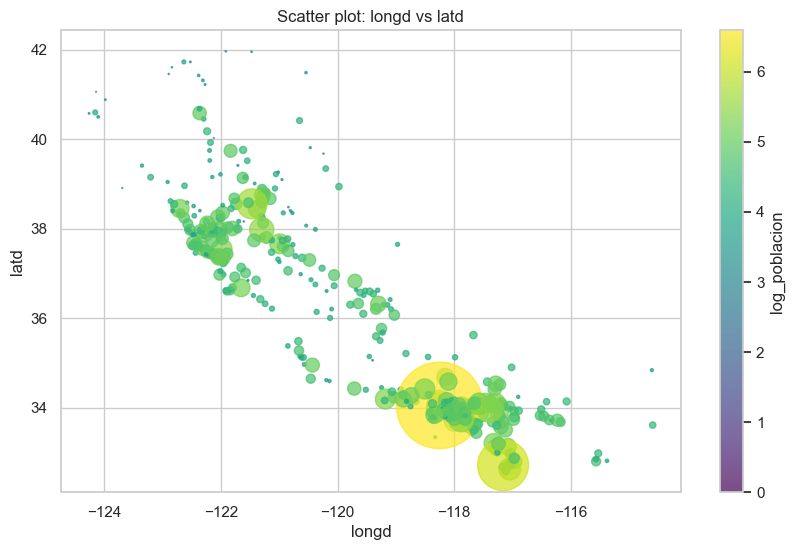

In [ ]:
# Columna log_poblacion
df_cities["log_poblacion"] = np.log10(df_cities["population_total"])

# Gráfico: longitud vs latitud
scatter_plot(
    df=df_cities,
    x_col="longd",
    y_col="latd",
    cat_col="log_poblacion",   # color por log de población
    size="population_total",   # tamaño por población
    scale=1/1000,              # escala del tamaño
    legend_mode="colorbar"
)

In [ ]:
# Dataset Titanic
df_titanic = pd.read_csv("titanic.csv")

# Vista inicial
display(df_titanic.head())
display(df_titanic.info())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


None

Tasa de supervivencia: 0.3838383838383838
Tasa de mortalidad: 0.6161616161616161


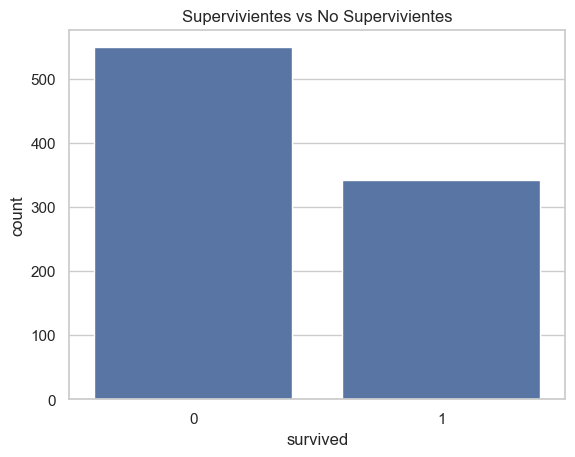

In [ ]:
# Tasa Survival
survival_rate = df_titanic["survived"].mean()
print("Tasa de supervivencia:", survival_rate)
print("Tasa de mortalidad:", 1 - survival_rate)

# Gráfico
sns.countplot(data=df_titanic, x="survived")
plt.title("Supervivientes vs No Supervivientes")
plt.show()

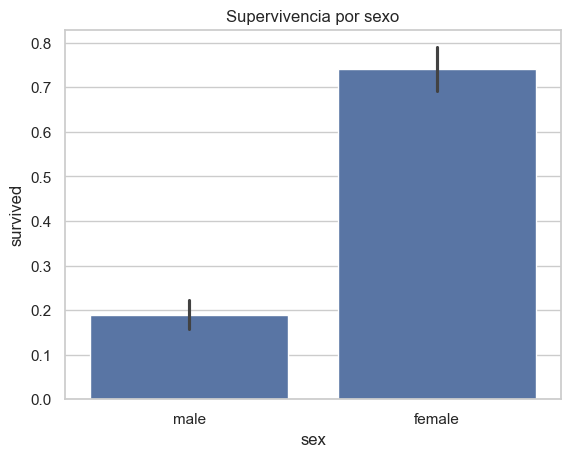

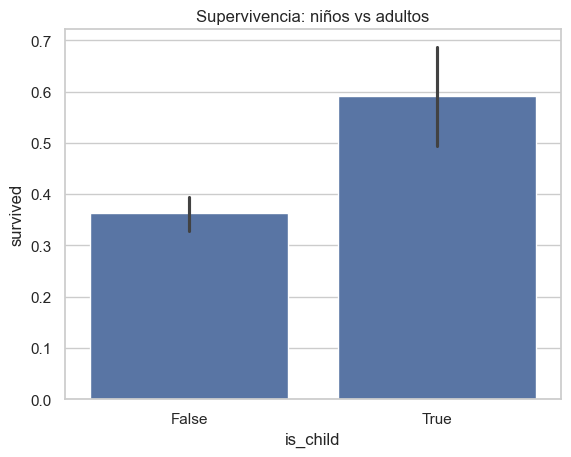

In [ ]:
# Columna niño
df_titanic["is_child"] = df_titanic["age"] < 16

# Supervivencia por sexo
sns.barplot(data=df_titanic, x="sex", y="survived")
plt.title("Supervivencia por sexo")
plt.show()

# Supervivencia niños /adultos
sns.barplot(data=df_titanic, x="is_child", y="survived")
plt.title("Supervivencia: niños vs adultos")
plt.show()

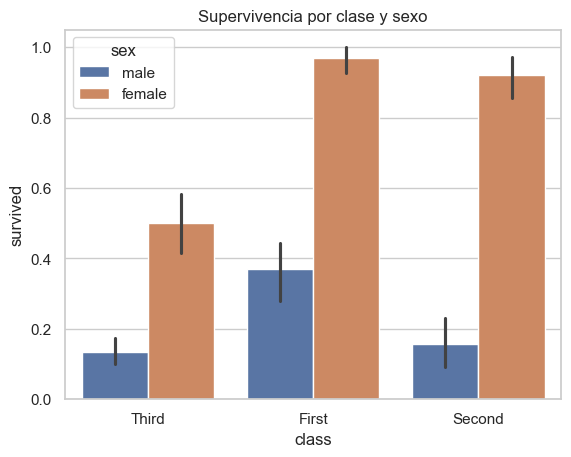

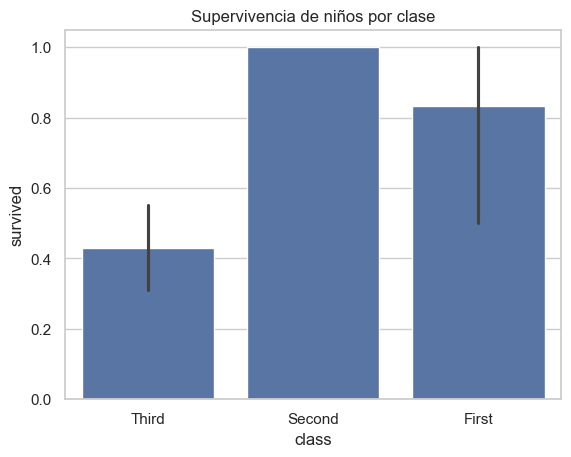

In [11]:
sns.barplot(data=df_titanic, x="class", y="survived", hue="sex")
plt.title("Supervivencia por clase y sexo")
plt.show()

sns.barplot(data=df_titanic[df_titanic["is_child"]==True], x="class", y="survived")
plt.title("Supervivencia de niños por clase")
plt.show()

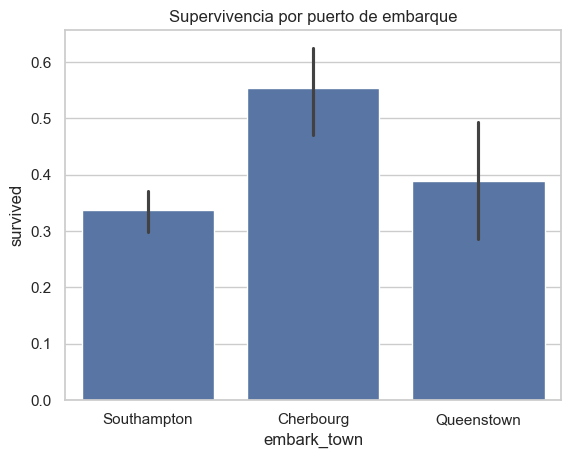

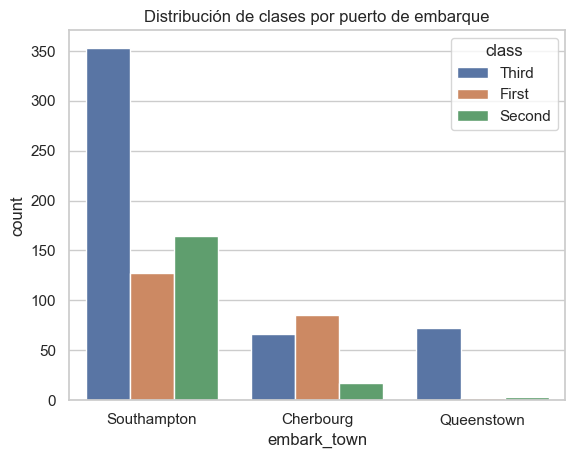

In [12]:
sns.barplot(data=df_titanic, x="embark_town", y="survived")
plt.title("Supervivencia por puerto de embarque")
plt.show()

sns.countplot(data=df_titanic, x="embark_town", hue="class")
plt.title("Distribución de clases por puerto de embarque")
plt.show()